In [1]:
 # Importing dependecies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [4]:
# Setup pandas to import the dataset
folder_path = 'B:/Bootcamp/Final Project Data Analysis'
path = folder_path + '/synthetic_beverage_sales_data.csv'
df = pd.read_csv(path)
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23


# Data Understanding


In [5]:
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Order_ID       object 
 1   Customer_ID    object 
 2   Customer_Type  object 
 3   Product        object 
 4   Category       object 
 5   Unit_Price     float64
 6   Quantity       int64  
 7   Discount       float64
 8   Total_Price    float64
 9   Region         object 
 10  Order_Date     object 
dtypes: float64(3), int64(1), object(7)
memory usage: 755.3+ MB


In [7]:
df.shape

(8999910, 11)

**Summary**:
1. The data contains 8999910 rows and 11 columns
2. There are 11 columns which 4 of them are numerical and rest are categorical
3. Order_Date data type is an object and need to be transformed into datetime
4. Because the data is too big I will take random sampling to represent the data in smaller scale to make it easier to process

# Random Sampling

In [12]:
# Slovin Method
import math
def slovin(population):
    sample =  math.ceil(len(population) / (1 + len(population) * 0.01**2))
    print('Sample size based on slovin : ', sample)

# Simple random function
def simple_random(data, size):
    dt = data.sample(n = size, random_state = 42)
    return dt

In [13]:
# Find out what is the appropriate sample size
slovin(df)

Sample size based on slovin :  9989


In [14]:
# Random sampling the data
random_sampling = simple_random(df, 9989)
random_sampling.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
4990465,ORD1663596,CUS5073,B2B,Hohes C Orange,Juices,1.87,74,0.10,124.54,Niedersachsen,2023-11-29
5995542,ORD1999010,CUS141,B2B,Fritz-Kola,Soft Drinks,1.87,18,0.05,31.98,Bremen,2021-05-13
1044351,ORD347756,CUS562,B2B,Merlot,Alcoholic Beverages,12.04,71,0.15,726.61,Thüringen,2021-04-21
1802181,ORD600360,CUS7718,B2B,Moët & Chandon,Alcoholic Beverages,64.91,91,0.10,5316.13,Hamburg,2021-08-23
6900691,ORD2300591,CUS6160,B2C,Granini Apple,Juices,1.64,4,0.00,6.56,Sachsen,2022-10-16


Let's compare the original dataset and sample

In [16]:
num_col = ['Quantity', 'Unit_Price', 'Discount', 'Total_Price']
catg_col = ['Customer_Type', 'Product', 'Category', 'Region', 'Order_Date']

In [17]:
df[num_col].describe()

,Quantity,Unit_Price,Discount,Total_Price
count,8999910.00,8999910.00,8999910.00,8999910.00
mean,23.14,5.82,0.03,130.74
std,26.89,14.70,0.04,509.69
min,1.00,0.32,0.00,0.30
25%,6.00,1.05,0.00,8.40
50%,11.00,1.75,0.00,21.14
75%,30.00,3.21,0.05,69.49
max,100.00,169.53,0.15,14295.30


In [18]:
random_sampling[num_col].describe()

,Quantity,Unit_Price,Discount,Total_Price
count,9989.00,9989.00,9989.00,9989.00
mean,22.79,5.88,0.03,135.24
std,26.57,15.10,0.04,528.66
min,1.00,0.33,0.00,0.35
25%,6.00,1.05,0.00,8.30
50%,11.00,1.75,0.00,20.69
75%,29.00,3.19,0.05,67.97
max,100.00,138.72,0.15,10111.96


Based on the describe we can see that the sample dataset is similar to the full dataset and it can be used as the representative

# Data Cleaning

## Missing Value Handling

In [19]:
random_sampling.isnull().sum()

Order_ID         0
Customer_ID      0
Customer_Type    0
Product          0
Category         0
Unit_Price       0
Quantity         0
Discount         0
Total_Price      0
Region           0
Order_Date       0
dtype: int64

In [20]:
for column in random_sampling.columns.drop(['Order_ID', 'Customer_ID']):
  print(f'============={column}=============')
  display(random_sampling[column].value_counts())
  print()

=============Customer_Type=============


Customer_Type
B2C    6451
B2B    3538
Name: count, dtype: int64


=============Product=============


Product
Mango Juice            381
Hohes C Orange         367
Passion Fruit Juice    361
Cranberry Juice        356
Tomato Juice           351
Granini Apple          349
Rauch Multivitamin     336
San Pellegrino         303
Selters                302
Vittel                 292
Vio Wasser             290
Evian                  286
Volvic Touch           277
Apollinaris            273
Volvic                 270
Gerolsteiner           256
Fritz-Kola             244
Sprite                 240
Rockstar               214
Coca-Cola              210
Mountain Dew           207
Monster                200
Pepsi                  199
Schwip Schwap          196
Fanta                  188
Red Bull               180
Club Mate              179
Mezzo Mix              177
Beck's                 170
Krombacher             152
Riesling               144
Jever                  139
Bacardi                139
Tanqueray              136
Warsteiner             134
Chardonnay             131
Jack Daniels        


=============Category=============


...

Total_Price
6.93      23
14.40     22
4.95      21
4.64      21
13.02     21
          ..
55.72      1
101.11     1
27.28      1
37.70      1
61.24      1
Name: count, Length: 4266, dtype: int64


=============Region=============


Region
Hamburg                   710
Niedersachsen             666
Nordrhein-Westfalen       663
Sachsen-Anhalt            654
Rheinland-Pfalz           650
Saarland                  643
Mecklenburg-Vorpommern    638
Bremen                    629
Sachsen                   627
Baden-Württemberg         624
Hessen                    612
Schleswig-Holstein        609
Bayern                    596
Berlin                    576
Thüringen                 562
Brandenburg               530
Name: count, dtype: int64


=============Order_Date=============


Order_Date
2021-11-15    23
2022-08-31    21
2021-04-02    20
2023-03-16    19
2023-07-20    18
              ..
2023-02-01     2
2023-06-19     2
2022-03-13     2
2022-10-27     2
2023-02-20     2
Name: count, Length: 1094, dtype: int64

Based on the value check above, there are no identified missing or incorrect value for each columns

## Duplicates Handling

In [21]:
len(random_sampling.drop_duplicates()) / len(random_sampling)

1.0

No duplicates found

## Outlier Handling

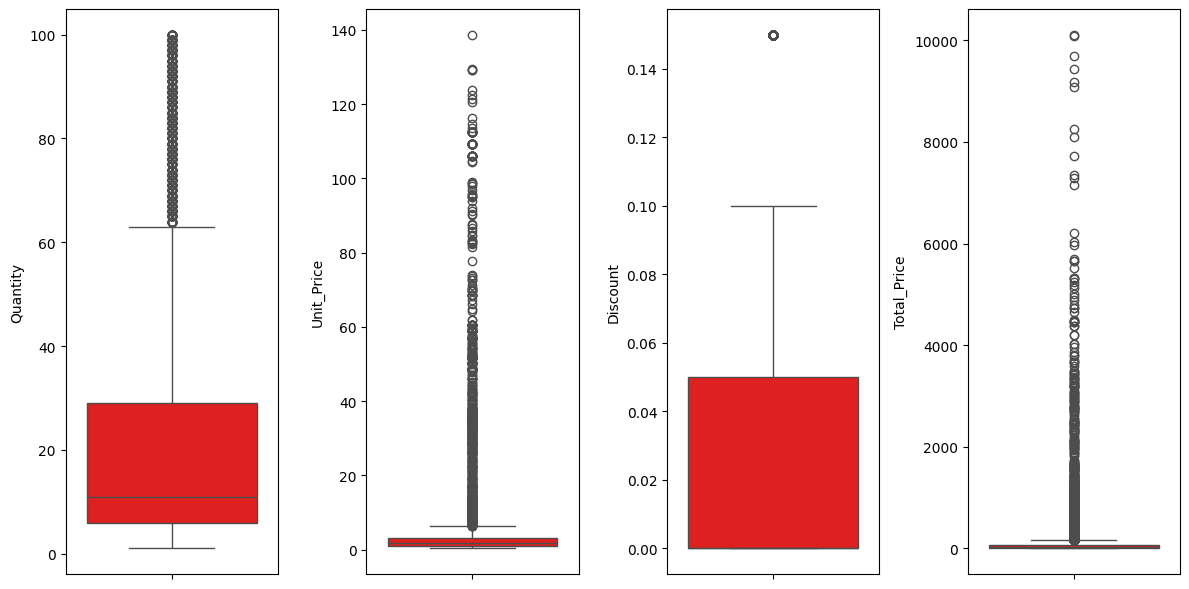

In [22]:
# Check for outlier
plt.figure(figsize=(12,6))
for i in range(0, len(num_col)):
    plt.subplot(1, len(num_col), i+1)
    sns.boxplot(y=random_sampling[num_col[i]], color='red')
    plt.tight_layout()

Based on the plot above there seems outlier for all of the columns, but the justification is that the column variables made it still makes sense because the value of quantity and total_price is variates and still makes sense as long it is not below 0.

In [23]:
for i in num_col:
    print(random_sampling[i].value_counts())

Quantity
8     515
9     502
3     483
5     482
10    475
     ... 
75     26
62     26
81     25
56     25
53     25
Name: count, Length: 100, dtype: int64
Unit_Price
0.96      148
0.93      145
0.99      142
1.59      134
3.21      133
         ... 
40.20       1
30.56       1
54.41       1
120.53      1
104.30      1
Name: count, Length: 926, dtype: int64
Discount
0.00    6451
0.05    1615
0.10    1494
0.15     429
Name: count, dtype: int64
Total_Price
6.93      23
14.40     22
4.95      21
4.64      21
13.02     21
          ..
55.72      1
101.11     1
27.28      1
37.70      1
61.24      1
Name: count, Length: 4266, dtype: int64


All the values still makes sense and decided to continue to analyze

# Data Manipulation

In [24]:
random_sampling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9989 entries, 4990465 to 3638266
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       9989 non-null   object 
 1   Customer_ID    9989 non-null   object 
 2   Customer_Type  9989 non-null   object 
 3   Product        9989 non-null   object 
 4   Category       9989 non-null   object 
 5   Unit_Price     9989 non-null   float64
 6   Quantity       9989 non-null   int64  
 7   Discount       9989 non-null   float64
 8   Total_Price    9989 non-null   float64
 9   Region         9989 non-null   object 
 10  Order_Date     9989 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 936.5+ KB


1. Transform order_date data type into datetime

In [25]:
random_sampling['Order_Date'] = pd.to_datetime(random_sampling['Order_Date'])
random_sampling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9989 entries, 4990465 to 3638266
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       9989 non-null   object        
 1   Customer_ID    9989 non-null   object        
 2   Customer_Type  9989 non-null   object        
 3   Product        9989 non-null   object        
 4   Category       9989 non-null   object        
 5   Unit_Price     9989 non-null   float64       
 6   Quantity       9989 non-null   int64         
 7   Discount       9989 non-null   float64       
 8   Total_Price    9989 non-null   float64       
 9   Region         9989 non-null   object        
 10  Order_Date     9989 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 936.5+ KB


In [26]:
random_sampling.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
4990465,ORD1663596,CUS5073,B2B,Hohes C Orange,Juices,1.87,74,0.10,124.54,Niedersachsen,2023-11-29
5995542,ORD1999010,CUS141,B2B,Fritz-Kola,Soft Drinks,1.87,18,0.05,31.98,Bremen,2021-05-13
1044351,ORD347756,CUS562,B2B,Merlot,Alcoholic Beverages,12.04,71,0.15,726.61,Thüringen,2021-04-21
1802181,ORD600360,CUS7718,B2B,Moët & Chandon,Alcoholic Beverages,64.91,91,0.10,5316.13,Hamburg,2021-08-23
6900691,ORD2300591,CUS6160,B2C,Granini Apple,Juices,1.64,4,0.00,6.56,Sachsen,2022-10-16


In [27]:
# Split The Datetime
random_sampling["Year"] = random_sampling['Order_Date'].dt.year
random_sampling['Month'] = random_sampling['Order_Date'].dt.month_name()
random_sampling['Day_of_Week'] = random_sampling['Order_Date'].dt.day_name()
random_sampling.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Year,Month,Day_of_Week
4990465,ORD1663596,CUS5073,B2B,Hohes C Orange,Juices,1.87,74,0.10,124.54,Niedersachsen,2023-11-29,2023,November,Wednesday
5995542,ORD1999010,CUS141,B2B,Fritz-Kola,Soft Drinks,1.87,18,0.05,31.98,Bremen,2021-05-13,2021,May,Thursday
1044351,ORD347756,CUS562,B2B,Merlot,Alcoholic Beverages,12.04,71,0.15,726.61,Thüringen,2021-04-21,2021,April,Wednesday
1802181,ORD600360,CUS7718,B2B,Moët & Chandon,Alcoholic Beverages,64.91,91,0.10,5316.13,Hamburg,2021-08-23,2021,August,Monday
6900691,ORD2300591,CUS6160,B2C,Granini Apple,Juices,1.64,4,0.00,6.56,Sachsen,2022-10-16,2022,October,Sunday


In [28]:
# Extract to CSV for viz
random_sampling.to_csv('clean_beverage_sales.csv', index=False)